In [1]:
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np


In [2]:
import importlib
import utils.koopman as koopman_module
importlib.reload(koopman_module)
KoopmanEstimator = koopman_module.KoopmanEstimator

In [3]:
# data downloaded from here: https://psl.noaa.gov/data/gridded/data.noaa.ersst.v6.html

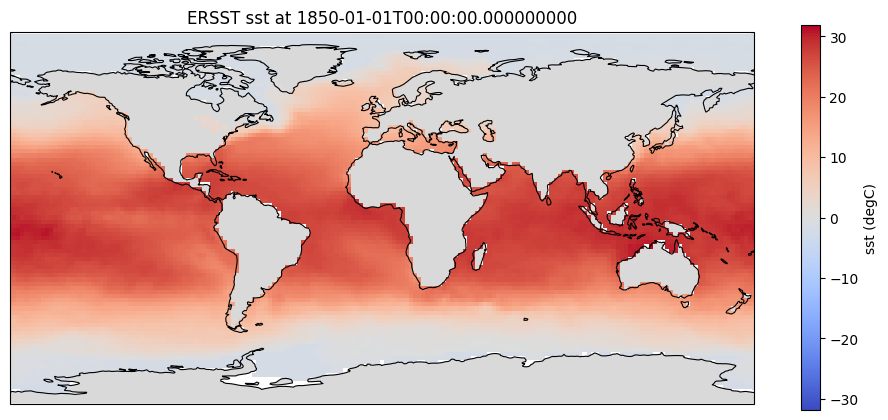

In [4]:
# Load SST data from the provided NetCDF file
data_path = Path("/home/nate/Documents/Courses/dynamical_systems_course/data/sst.mnmean.nc")
ds = xr.open_dataset(data_path)

# Use SST variable and first time step
sst = ds["sst"]
sst_one_time = sst.isel(time=0)

# Plot on a global map using Cartopy
fig = plt.figure(figsize=(12, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
sst_one_time.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="coolwarm",
    add_colorbar=True,
    cbar_kwargs={"label": f"sst ({sst.attrs.get('units', '')})"},
)
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=0)
ax.set_global()
time_label = str(sst_one_time["time"].values) if "time" in sst_one_time.coords else "index 0"
ax.set_title(f"ERSST sst at {time_label}")
plt.show()

In [5]:


climatology = sst.groupby("time.month").mean("time")

# Monthly anomalies: remove climatological seasonal cycle
sst_anom = sst.groupby("time.month") - climatology

# Linear detrend at each grid point
t_idx = xr.DataArray(
    np.arange(sst.sizes["time"], dtype=float),
    dims=["time"],
    coords={"time": sst["time"]},
)
coef = sst_anom.polyfit(dim="time", deg=1, skipna=True)
trend = xr.polyval(t_idx, coef["polyfit_coefficients"])
sst_dt = sst_anom - trend

sst_for_pca = sst_dt

print("Created preprocessed field: monthly anomalies + linear detrend")
print(f"sst_for_pca shape: {sst_for_pca.shape}")
print(f"dims: {sst_for_pca.dims}")

Created preprocessed field: monthly anomalies + linear detrend
sst_for_pca shape: (2116, 89, 180)
dims: ('time', 'lat', 'lon')


Valid spatial points used: 11074 / 16020
PCs needed for 90% variance: 80
Cumulative explained variance at that cutoff: 90.15%
Reduced data shape (time, n_pcs): (2116, 80)


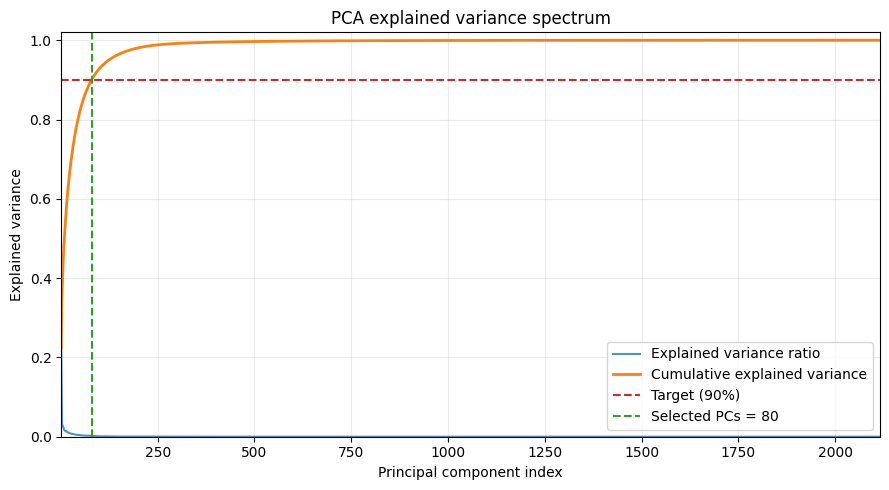

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Area-weighted PCA on preprocessed SST (monthly anomalies + detrended), using sqrt(cos(latitude)) weights
if "sst_for_pca" not in globals():
    raise RuntimeError("Run the preprocessing cell first to create `sst_for_pca`.")

X = sst_for_pca.values  # shape: (time, lat, lon)
lat = sst_for_pca["lat"].values
lon = sst_for_pca["lon"].values

if X.ndim != 3:
    raise ValueError(f"Expected SST with dims (time, lat, lon), got shape {X.shape}")

nt, nlat, nlon = X.shape
X2 = X.reshape(nt, nlat * nlon)

# Keep only spatial points that are finite for all times
valid_space = np.all(np.isfinite(X2), axis=0)
Xv_raw = X2[:, valid_space]

# Remove any residual temporal mean
pca_mean_valid = Xv_raw.mean(axis=0, keepdims=True)
Xv = Xv_raw - pca_mean_valid

# Build latitude weights per valid spatial point
lat2d = np.repeat(lat[:, None], nlon, axis=1)
lat_flat = lat2d.reshape(-1)
lat_valid = lat_flat[valid_space]
coslat = np.cos(np.deg2rad(lat_valid))
coslat = np.clip(coslat, 0.0, None)
w = np.sqrt(coslat)

# Apply weights and perform SVD-based PCA
Xw = Xv * w[None, :]
U, S, Vt = np.linalg.svd(Xw, full_matrices=False)
explained_ratio = (S ** 2) / np.sum(S ** 2)
cum_explained = np.cumsum(explained_ratio)

target = 0.90
n_pcs = int(np.searchsorted(cum_explained, target) + 1)

# Reduced temporal representation (time x n_pcs)
pcs = U[:, :n_pcs] * S[:n_pcs]

# Store PCA metadata for inverse transform back to ambient space
pca_valid_space = valid_space
pca_w = w
pca_components = Vt[:n_pcs, :]
pca_mean_valid = pca_mean_valid
pca_nlat = nlat
pca_nlon = nlon

# EOFs in original (unweighted) variable units at valid points
eps = 1e-12
eofs_valid = pca_components / np.maximum(pca_w[None, :], eps)

print(f"Valid spatial points used: {Xv.shape[1]} / {nlat * nlon}")
print(f"PCs needed for {target:.0%} variance: {n_pcs}")
print(f"Cumulative explained variance at that cutoff: {cum_explained[n_pcs - 1]:.2%}")
print(f"Reduced data shape (time, n_pcs): {pcs.shape}")

# Plot explained variance ratio and cumulative explained variance
pc_idx = np.arange(1, len(explained_ratio) + 1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pc_idx, explained_ratio, label="Explained variance ratio", color="tab:blue", alpha=0.8)
ax.plot(pc_idx, cum_explained, label="Cumulative explained variance", color="tab:orange", linewidth=2.0)
ax.axhline(target, color="tab:red", linestyle="--", linewidth=1.5, label=f"Target ({target:.0%})")
ax.axvline(n_pcs, color="tab:green", linestyle="--", linewidth=1.5, label=f"Selected PCs = {n_pcs}")
ax.set_xlabel("Principal component index")
ax.set_ylabel("Explained variance")
ax.set_title("PCA explained variance spectrum")
ax.set_xlim(1, len(explained_ratio))
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
def make_lagged(Z_in, lag):
    if lag < 1:
        raise ValueError("lag must be >= 1")
    if Z_in.shape[0] < lag:
        raise ValueError(f"Need at least {lag} samples, got {Z_in.shape[0]}")
    rows = [Z_in[t - lag + 1 : t + 1].reshape(-1) for t in range(lag - 1, Z_in.shape[0])]
    return np.asarray(rows)

def extract_current_state(E, n_state):
    return E[..., -n_state:]

def recursive_rollout_lagged(model, e0, n_steps, n_state, lag):
    """Demo2-style recursive rollout: one-step predict, then re-compose lag state."""
    out = np.zeros((n_steps, e0.shape[-1]), dtype=float)
    out[0] = e0
    for t in range(1, n_steps):
        pred_obj = model.predict(out[t - 1], steps=1)
        pred_seq = pred_obj[0] if isinstance(pred_obj, (tuple, list)) else pred_obj
        pred_e = np.asarray(pred_seq).reshape(1, -1)[0]

        z_next = extract_current_state(pred_e, n_state).reshape(-1)
        if lag == 1:
            out[t] = z_next
        else:
            out[t] = np.concatenate([out[t - 1, n_state:], z_next])
    return out

def pcs_to_ambient(pcs_arr, pca_components, pca_w, pca_mean_valid, pca_valid_space, pca_nlat, pca_nlon):
    eps = 1e-12
    Xw_hat = pcs_arr @ pca_components
    Xv_hat = Xw_hat / np.maximum(pca_w[None, :], eps)
    Xv_hat = Xv_hat + pca_mean_valid
    X2_hat = np.full((pcs_arr.shape[0], pca_nlat * pca_nlon), np.nan, dtype=float)
    X2_hat[:, pca_valid_space] = Xv_hat
    return X2_hat.reshape(pcs_arr.shape[0], pca_nlat, pca_nlon)

def nino12_index(field_tll, time_coord, lat, lon):
    da = xr.DataArray(
        field_tll,
        dims=("time", "lat", "lon"),
        coords={"time": time_coord, "lat": lat, "lon": lon},
        name="sst",
    )
    lon360 = (da["lon"] % 360)
    da = da.assign_coords(lon=lon360).sortby("lon")
    region = da.where(
        (da["lat"] >= -10) & (da["lat"] <= 0) & (da["lon"] >= 270) & (da["lon"] <= 280),
        drop=True,
    )
    if region.sizes.get("lat", 0) == 0 or region.sizes.get("lon", 0) == 0:
        raise RuntimeError("Nino1+2 region selection is empty; check lat/lon coordinates.")
    wlat = np.cos(np.deg2rad(region["lat"]))
    return region.weighted(wlat).mean(dim=("lat", "lon"))

def rel_err_finite(pred, true):
    mask = np.isfinite(pred) & np.isfinite(true)
    if not np.any(mask):
        return np.nan
    num = np.linalg.norm(pred[mask] - true[mask])
    den = np.linalg.norm(true[mask])
    return num / den if den > 0 else np.nan

def nino_skill(pred_arr, true_arr):
    pred = np.asarray(pred_arr, dtype=float)
    true = np.asarray(true_arr, dtype=float)
    mask = np.isfinite(pred) & np.isfinite(true)
    if np.sum(mask) < 12:
        return -np.inf, np.nan, np.nan
    p = pred[mask]
    t = true[mask]
    t_std = np.std(t)
    if t_std < 1e-12:
        return -np.inf, np.nan, np.nan
    rmse = np.sqrt(np.mean((p - t) ** 2))
    corr = np.corrcoef(p, t)[0, 1] if np.std(p) > 1e-12 else np.nan
    if not np.isfinite(corr):
        corr = -1.0
    score = corr - (rmse / t_std)
    return score, rmse, corr

def nino_rmse_corr(pred, true):
    mask = np.isfinite(pred) & np.isfinite(true)
    p = pred[mask]
    t = true[mask]
    rmse = np.sqrt(np.mean((p - t) ** 2)) if len(p) else np.nan
    corr = np.corrcoef(p, t)[0, 1] if len(p) > 2 and np.std(p) > 1e-12 and np.std(t) > 1e-12 else np.nan
    return rmse, corr

In [8]:
required_vars = [
    "pcs",
    "pca_components",
    "pca_w",
    "pca_valid_space",
    "pca_mean_valid",
    "pca_nlat",
    "pca_nlon",
    "sst_for_pca",
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Run preprocessing/PCA cell first. Missing: {missing}")

required_funcs = [
    "make_lagged",
    "extract_current_state",
    "recursive_rollout_lagged",
    "pcs_to_ambient",
    "nino12_index",
    "rel_err_finite",
    "nino_skill",
    "nino_rmse_corr",
]
missing_funcs = [f for f in required_funcs if f not in globals()]
if missing_funcs:
    raise RuntimeError(f"Run the function-utility cell first. Missing: {missing_funcs}")

Z = pcs
n_samples = Z.shape[0]
if n_samples < 100:
    raise ValueError(f"Need more time samples for tuning/training/testing, got {n_samples}")

split = int(0.8 * n_samples)
Z_train = Z[:split]
Z_test = Z[split:]

lat = sst_for_pca["lat"].values
lon = sst_for_pca["lon"].values
time_all = sst_for_pca["time"].values
time_train = time_all[:split]
time_test = time_all[split:]

# Validation split inside training period for hyperparameter tuning
fit_cut = int(0.8 * len(Z_train))
Z_fit = Z_train[:fit_cut]
Z_val = Z_train[fit_cut:]
time_val = time_train[fit_cut:]
X_val_true = pcs_to_ambient(
    Z_val,
    pca_components,
    pca_w,
    pca_mean_valid,
    pca_valid_space,
    pca_nlat,
    pca_nlon,
    )
nino_val_true = nino12_index(X_val_true, time_val, lat, lon).values

candidate_configs = []
for lag in [1, 3, 6, 12]:
    for reg in [1e-8, 1e-6, 1e-4]:
        candidate_configs.append({
            "lag": lag,
            "observable_type": "linear",
            "include_bias": True,
            "reg": reg,
            "n_fourier_features": 0,
            "gamma": None,
        })
    for nff in [200, 600]:
        for gamma in [0.1, 0.5, 1.0]:
            for reg in [1e-8, 1e-6]:
                candidate_configs.append({
                    "lag": lag,
                    "observable_type": "rff",
                    "include_bias": False,
                    "reg": reg,
                    "n_fourier_features": nff,
                    "gamma": gamma,
                })

results = []
for cfg in candidate_configs:
    lag = cfg["lag"]
    if len(Z_fit) < lag + 5:
        continue
    try:
        E_fit = make_lagged(Z_fit, lag)
        model = KoopmanEstimator(
            observable_type=cfg["observable_type"],
            n_fourier_features=max(1, cfg["n_fourier_features"]),
            gamma=cfg["gamma"],
            include_bias=cfg["include_bias"],
            include_state=True,
            state_first=True,
            reg=cfg["reg"],
            random_state=0,
        )
        model.fit(E_fit)

        E_val_pred = recursive_rollout_lagged(
            model,
            e0=E_fit[-1],
            n_steps=len(Z_val),
            n_state=Z.shape[1],
            lag=lag,
        )
        Z_val_pred = extract_current_state(E_val_pred, Z.shape[1])

        X_val_pred = pcs_to_ambient(
            Z_val_pred,
            pca_components,
            pca_w,
            pca_mean_valid,
            pca_valid_space,
            pca_nlat,
            pca_nlon,
            )
        nino_val_pred = nino12_index(X_val_pred, time_val, lat, lon).values

        score, rmse, corr = nino_skill(nino_val_pred, nino_val_true)
        results.append({
            "cfg": cfg,
            "score": score,
            "rmse": rmse,
            "corr": corr,
        })
    except Exception:
        continue

if not results:
    raise RuntimeError("No valid Koopman configuration found during tuning.")

results_sorted = sorted(results, key=lambda d: d["score"], reverse=True)
best = results_sorted[0]
best_cfg = best["cfg"]

print("Top 8 validation configs (score = corr - RMSE/std(true)):")
for i, r in enumerate(results_sorted[:8], start=1):
    c = r["cfg"]
    print(
        f"{i:2d}. lag={c['lag']:2d}, obs={c['observable_type']}, nff={c['n_fourier_features']:3d}, "
        f"gamma={c['gamma']}, reg={c['reg']:.0e}, score={r['score']:.3f}, rmse={r['rmse']:.3f}, corr={r['corr']:.3f}"
    )

print("\nSelected config:")
print(best_cfg)

Top 8 validation configs (score = corr - RMSE/std(true)):
 1. lag= 1, obs=rff, nff=200, gamma=1.0, reg=1e-08, score=-0.843, rmse=1.032, corr=0.218
 2. lag= 1, obs=linear, nff=  0, gamma=None, reg=1e-08, score=-0.908, rmse=0.979, corr=0.099
 3. lag= 1, obs=linear, nff=  0, gamma=None, reg=1e-06, score=-0.908, rmse=0.979, corr=0.099
 4. lag= 1, obs=linear, nff=  0, gamma=None, reg=1e-04, score=-0.908, rmse=0.979, corr=0.099
 5. lag= 3, obs=linear, nff=  0, gamma=None, reg=1e-04, score=-0.928, rmse=0.981, corr=0.080
 6. lag= 3, obs=linear, nff=  0, gamma=None, reg=1e-06, score=-0.928, rmse=0.981, corr=0.080
 7. lag= 3, obs=linear, nff=  0, gamma=None, reg=1e-08, score=-0.928, rmse=0.981, corr=0.080
 8. lag= 1, obs=rff, nff=200, gamma=0.5, reg=1e-08, score=-0.987, rmse=1.108, corr=0.153

Selected config:
{'lag': 1, 'observable_type': 'rff', 'include_bias': False, 'reg': 1e-08, 'n_fourier_features': 200, 'gamma': 1.0}



Reduced dimension used for Koopman fit: 80
Lag embedding used: 1
Train samples: 1692, Test samples: 424
Relative train error (ambient space, finite points): 1.077e+00
Relative test error  (ambient space, finite points): 1.203e+00
Nino1+2 train RMSE=1.173, corr=-0.018
Nino1+2 test  RMSE=1.241, corr=-0.042
Finite fraction in decoded test field: 0.691
Finite fraction in test Nino1+2 index: 1.000
Top 10 Koopman eigenvalues by magnitude:
[0.97744533+0.j         0.95506368+0.j         0.91053694+0.00414916j
 0.91053694-0.00414916j 0.82627923+0.00368374j 0.82627923-0.00368374j
 0.76264519+0.j         0.74274865+0.0733013j  0.74274865-0.0733013j
 0.74342839+0.03308676j]


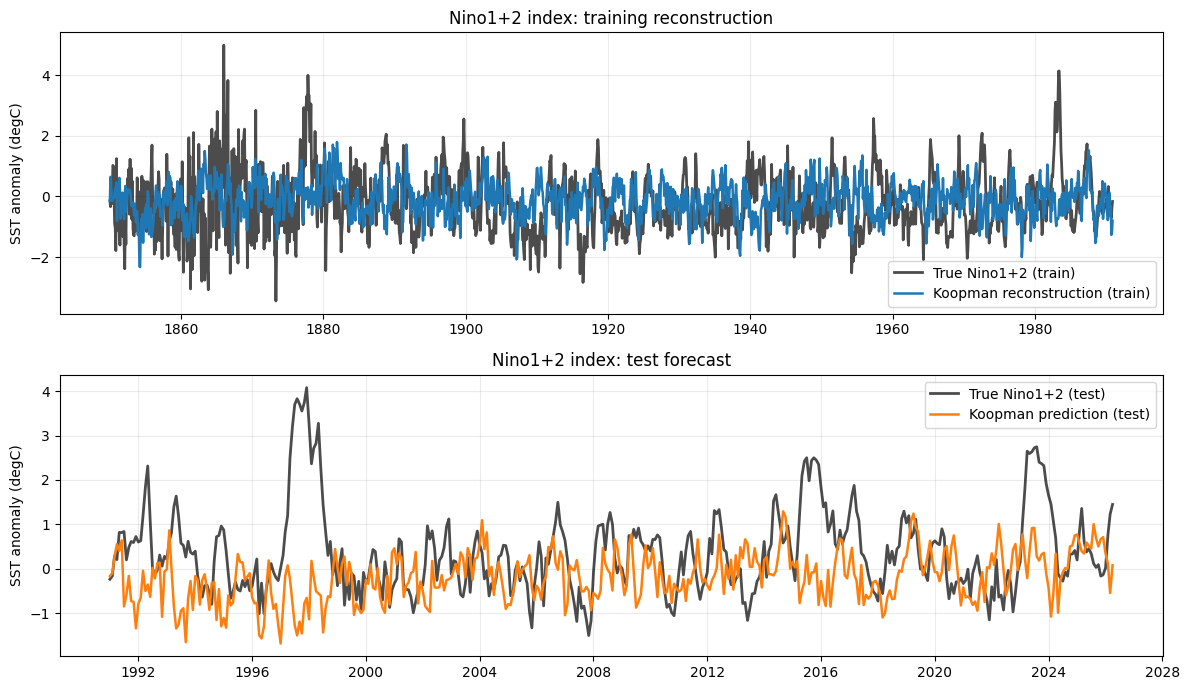

In [9]:
required_names = [
    "best_cfg",
    "Z",
    "Z_train",
    "Z_test",
    "time_train",
    "time_test",
    "lat",
    "lon",
]
missing_names = [n for n in required_names if n not in globals()]
if missing_names:
    raise RuntimeError(f"Run tuning cell first. Missing: {missing_names}")

# Refit best model on full training window and evaluate
lag_best = best_cfg["lag"]
E_train = make_lagged(Z_train, lag_best)
koop_model_sst = KoopmanEstimator(
    observable_type=best_cfg["observable_type"],
    n_fourier_features=max(1, best_cfg["n_fourier_features"]),
    gamma=best_cfg["gamma"],
    include_bias=best_cfg["include_bias"],
    include_state=True,
    state_first=True,
    reg=best_cfg["reg"],
    random_state=0,
)
koop_model_sst.fit(E_train)

E_train_rec = recursive_rollout_lagged(
    koop_model_sst,
    e0=E_train[0],
    n_steps=len(E_train),
    n_state=Z.shape[1],
    lag=lag_best,
    )
Z_train_rec = extract_current_state(E_train_rec, Z.shape[1])

E_test_pred = recursive_rollout_lagged(
    koop_model_sst,
    e0=E_train[-1],
    n_steps=len(Z_test),
    n_state=Z.shape[1],
    lag=lag_best,
    )
Z_test_pred = extract_current_state(E_test_pred, Z.shape[1])

# Align true train target to reconstruction start (lag_best-1)
Z_train_true_aligned = Z_train[lag_best - 1 :]
time_train_aligned = time_train[lag_best - 1 :]

X_train_true = pcs_to_ambient(
    Z_train_true_aligned,
    pca_components,
    pca_w,
    pca_mean_valid,
    pca_valid_space,
    pca_nlat,
    pca_nlon,
    )
X_train_rec = pcs_to_ambient(
    Z_train_rec,
    pca_components,
    pca_w,
    pca_mean_valid,
    pca_valid_space,
    pca_nlat,
    pca_nlon,
    )
X_test_true = pcs_to_ambient(
    Z_test,
    pca_components,
    pca_w,
    pca_mean_valid,
    pca_valid_space,
    pca_nlat,
    pca_nlon,
    )
X_test_pred = pcs_to_ambient(
    Z_test_pred,
    pca_components,
    pca_w,
    pca_mean_valid,
    pca_valid_space,
    pca_nlat,
    pca_nlon,
    )

nino_train_true = nino12_index(X_train_true, time_train_aligned, lat, lon)
nino_train_rec = nino12_index(X_train_rec, time_train_aligned, lat, lon)
nino_test_true = nino12_index(X_test_true, time_test, lat, lon)
nino_test_pred = nino12_index(X_test_pred, time_test, lat, lon)

train_rel_err_ambient = rel_err_finite(X_train_rec, X_train_true)
test_rel_err_ambient = rel_err_finite(X_test_pred, X_test_true)
train_nino_rmse, train_nino_corr = nino_rmse_corr(nino_train_rec.values, nino_train_true.values)
test_nino_rmse, test_nino_corr = nino_rmse_corr(nino_test_pred.values, nino_test_true.values)

eigvals_k = np.linalg.eigvals(koop_model_sst.K_)
idx = np.argsort(np.abs(eigvals_k))[::-1]
eigvals_sorted = eigvals_k[idx]

pred_finite_ratio = np.isfinite(X_test_pred).mean()
nino_pred_finite_ratio = np.isfinite(nino_test_pred.values).mean()

print(f"\nReduced dimension used for Koopman fit: {Z.shape[1]}")
print(f"Lag embedding used: {lag_best}")
print(f"Train samples: {len(Z_train)}, Test samples: {len(Z_test)}")
print(f"Relative train error (ambient space, finite points): {train_rel_err_ambient:.3e}")
print(f"Relative test error  (ambient space, finite points): {test_rel_err_ambient:.3e}")
print(f"Nino1+2 train RMSE={train_nino_rmse:.3f}, corr={train_nino_corr:.3f}")
print(f"Nino1+2 test  RMSE={test_nino_rmse:.3f}, corr={test_nino_corr:.3f}")
print(f"Finite fraction in decoded test field: {pred_finite_ratio:.3f}")
print(f"Finite fraction in test Nino1+2 index: {nino_pred_finite_ratio:.3f}")
print("Top 10 Koopman eigenvalues by magnitude:")
print(np.real_if_close(eigvals_sorted[:10]))

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
axes[0].plot(time_train_aligned, nino_train_true.values, label="True Nino1+2 (train)", color="black", linewidth=2, alpha=0.7)
axes[0].plot(time_train_aligned, nino_train_rec.values, label="Koopman reconstruction (train)", color="tab:blue", linewidth=1.8)
axes[0].set_title("Nino1+2 index: training reconstruction")
axes[0].set_ylabel("SST anomaly (degC)")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(time_test, nino_test_true.values, label="True Nino1+2 (test)", color="black", linewidth=2, alpha=0.7)
axes[1].plot(time_test, nino_test_pred.values, label="Koopman prediction (test)", color="tab:orange", linewidth=1.8)
axes[1].set_title("Nino1+2 index: test forecast")
axes[1].set_ylabel("SST anomaly (degC)")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

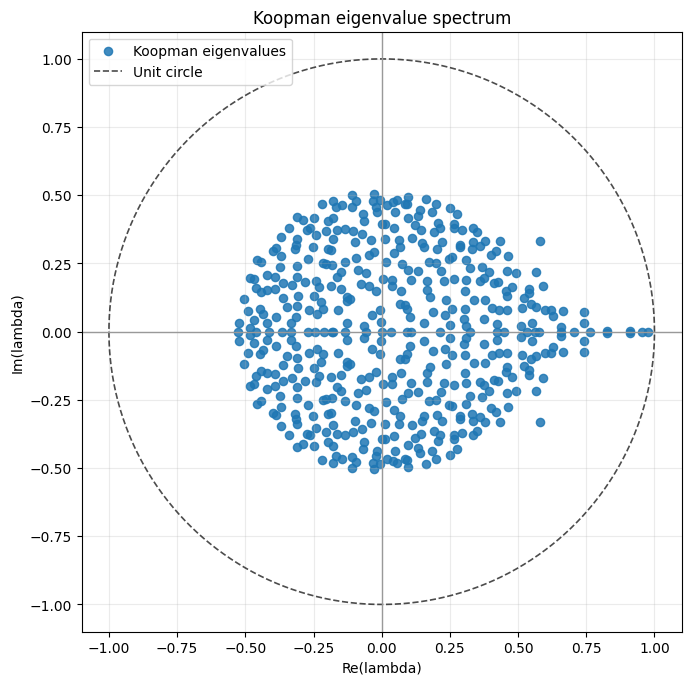

Top 10 eigenvalues by magnitude:
[0.97744533+0.j         0.95506368+0.j         0.91053694+0.00414916j
 0.91053694-0.00414916j 0.82627923+0.00368374j 0.82627923-0.00368374j
 0.76264519+0.j         0.74274865+0.0733013j  0.74274865-0.0733013j
 0.74342839+0.03308676j]


In [10]:
if "koop_model_sst" not in globals():
    raise RuntimeError("Run the final fit/evaluation cell first so `koop_model_sst` exists.")

eigvals = np.linalg.eigvals(koop_model_sst.K_)
idx = np.argsort(np.abs(eigvals))[::-1]
eigvals = eigvals[idx]

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(eigvals.real, eigvals.imag, s=35, alpha=0.85, label="Koopman eigenvalues")

# Unit circle for discrete-time stability reference
theta = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), "k--", linewidth=1.2, alpha=0.7, label="Unit circle")

ax.axhline(0.0, color="0.6", linewidth=1)
ax.axvline(0.0, color="0.6", linewidth=1)
ax.set_xlabel("Re(lambda)")
ax.set_ylabel("Im(lambda)")
ax.set_title("Koopman eigenvalue spectrum")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.25)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

print("Top 10 eigenvalues by magnitude:")
print(np.real_if_close(eigvals[:10]))

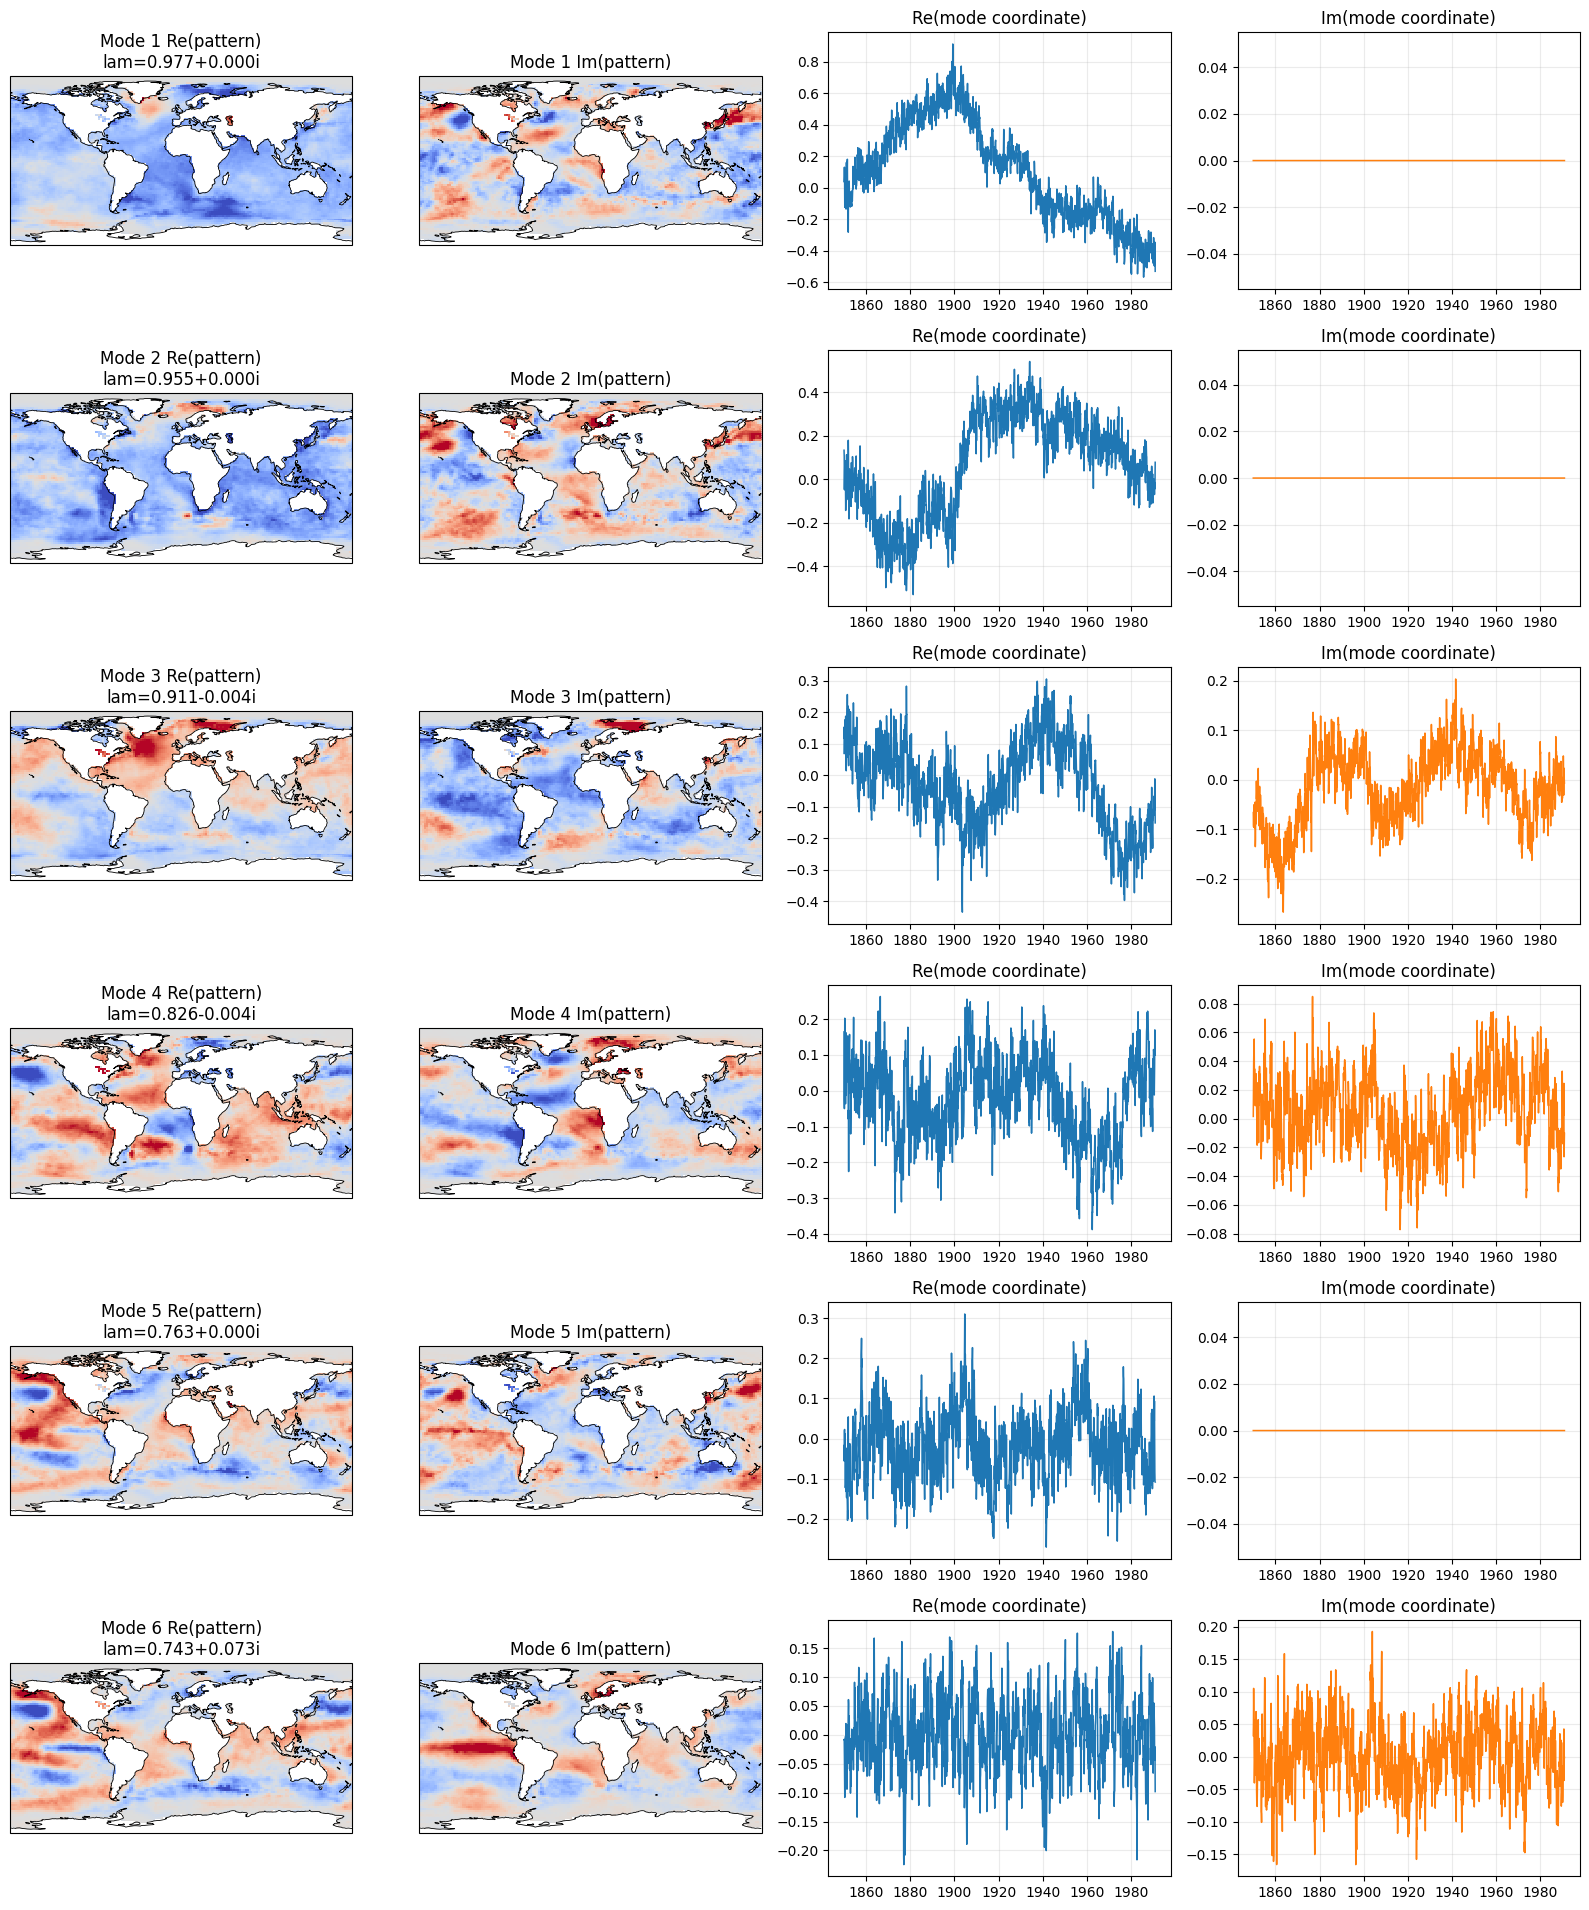

Selected unique eigenvalues (top-6 by magnitude, conjugate pairs counted once):
1. lambda = 0.977445+0.000000i, |lambda|=0.977445
2. lambda = 0.955064+0.000000i, |lambda|=0.955064
3. lambda = 0.910537-0.004149i, |lambda|=0.910546
4. lambda = 0.826279-0.003684i, |lambda|=0.826287
5. lambda = 0.762645+0.000000i, |lambda|=0.762645
6. lambda = 0.742749+0.073301i, |lambda|=0.746357


In [11]:
required_for_modes = [
    "koop_model_sst",
    "E_train",
    "lag_best",
    "Z",
    "time_train",
    "pca_components",
    "pca_w",
    "pca_valid_space",
    "pca_nlat",
    "pca_nlon",
]
missing_modes = [v for v in required_for_modes if v not in globals()]
if missing_modes:
    raise RuntimeError(f"Run tuning and final-fit cells first. Missing: {missing_modes}")

# Koopman eigendecomposition in lifted space
K = koop_model_sst.K_
eigvals, eigvecs_right = np.linalg.eig(K)
sort_idx = np.argsort(np.abs(eigvals))[::-1]
eigvals = eigvals[sort_idx]
eigvecs_right = eigvecs_right[:, sort_idx]

# Modal coordinates over training lagged trajectory
psi_train = koop_model_sst._lift(E_train)
mode_coords = psi_train @ eigvecs_right  # shape: (time_train_lagged, n_modes)

# Map lifted modes to CURRENT reduced-state coordinates (last n_state entries)
n_state = Z.shape[1]
B_current = koop_model_sst.B_[:, -n_state:]
modal_decoder = np.linalg.solve(eigvecs_right, B_current)  # rows correspond to modes

def decode_pcs_pattern(z_mode):
    """Decode one reduced-state mode vector to ambient SST anomaly pattern (complex-valued)."""
    z_mode = np.asarray(z_mode, dtype=complex).reshape(1, -1)
    xw = z_mode @ pca_components
    xv = xw / np.maximum(pca_w[None, :], 1e-12)
    x2 = np.full((1, pca_nlat * pca_nlon), np.nan + 0j, dtype=complex)
    x2[:, pca_valid_space] = xv
    return x2.reshape(pca_nlat, pca_nlon)

def safe_symmetric_vmax(field):
    vals = np.abs(field[np.isfinite(field)])
    if vals.size == 0:
        return 1.0
    vmax = np.nanpercentile(vals, 99)
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = np.nanmax(vals)
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0
    return float(vmax)

# Select top 6 unique modes by |lambda|, counting conjugate pairs as one
selected = []
seen = set()
for j, lam in enumerate(eigvals):
    key = (round(float(np.real(lam)), 10), round(abs(float(np.imag(lam))), 10))
    if key in seen:
        continue
    seen.add(key)
    selected.append(j)
    if len(selected) == 6:
        break

if len(selected) < 6:
    print(f"Warning: only found {len(selected)} unique modes.")

# Time axis for lagged train states
time_train_lagged = time_train[lag_best - 1 :]

# Plot: for each selected mode -> Re/Im spatial patterns + Re/Im modal time series
n_modes_plot = len(selected)
fig = plt.figure(figsize=(16, 3.2 * n_modes_plot))

for row, j in enumerate(selected):
    lam = eigvals[j]
    z_mode = modal_decoder[j, :]
    pattern = decode_pcs_pattern(z_mode)
    coord_ts = mode_coords[:, j]

    # Preserve the original ocean/land mask for both Re and Im pattern panels.
    mask = np.isfinite(np.real(pattern))
    pat_r = np.where(mask, np.real(pattern), np.nan)
    pat_i = np.where(mask, np.imag(pattern), np.nan)

    ax1 = plt.subplot(n_modes_plot, 4, 4 * row + 1, projection=ccrs.PlateCarree())
    vmax_r = safe_symmetric_vmax(pat_r)
    ax1.pcolormesh(
        lon, lat, pat_r,
        transform=ccrs.PlateCarree(),
        cmap="coolwarm",
        vmin=-vmax_r,
        vmax=vmax_r,
        shading="auto",
    )
    ax1.coastlines(linewidth=0.6)
    ax1.set_title(f"Mode {row+1} Re(pattern)\nlam={lam.real:.3f}{lam.imag:+.3f}i")

    ax2 = plt.subplot(n_modes_plot, 4, 4 * row + 2, projection=ccrs.PlateCarree())
    vmax_i = safe_symmetric_vmax(pat_i)
    ax2.pcolormesh(
        lon, lat, pat_i,
        transform=ccrs.PlateCarree(),
        cmap="coolwarm",
        vmin=-vmax_i,
        vmax=vmax_i,
        shading="auto",
    )
    ax2.coastlines(linewidth=0.6)
    ax2.set_title(f"Mode {row+1} Im(pattern)")

    ax3 = plt.subplot(n_modes_plot, 4, 4 * row + 3)
    ax3.plot(time_train_lagged, np.real(coord_ts), color="tab:blue", linewidth=1.1)
    ax3.set_title("Re(mode coordinate)")
    ax3.grid(alpha=0.25)

    ax4 = plt.subplot(n_modes_plot, 4, 4 * row + 4)
    ax4.plot(time_train_lagged, np.imag(coord_ts), color="tab:orange", linewidth=1.1)
    ax4.set_title("Im(mode coordinate)")
    ax4.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("Selected unique eigenvalues (top-6 by magnitude, conjugate pairs counted once):")
for k, j in enumerate(selected, start=1):
    lam = eigvals[j]
    print(f"{k}. lambda = {lam.real:.6f}{lam.imag:+.6f}i, |lambda|={abs(lam):.6f}")

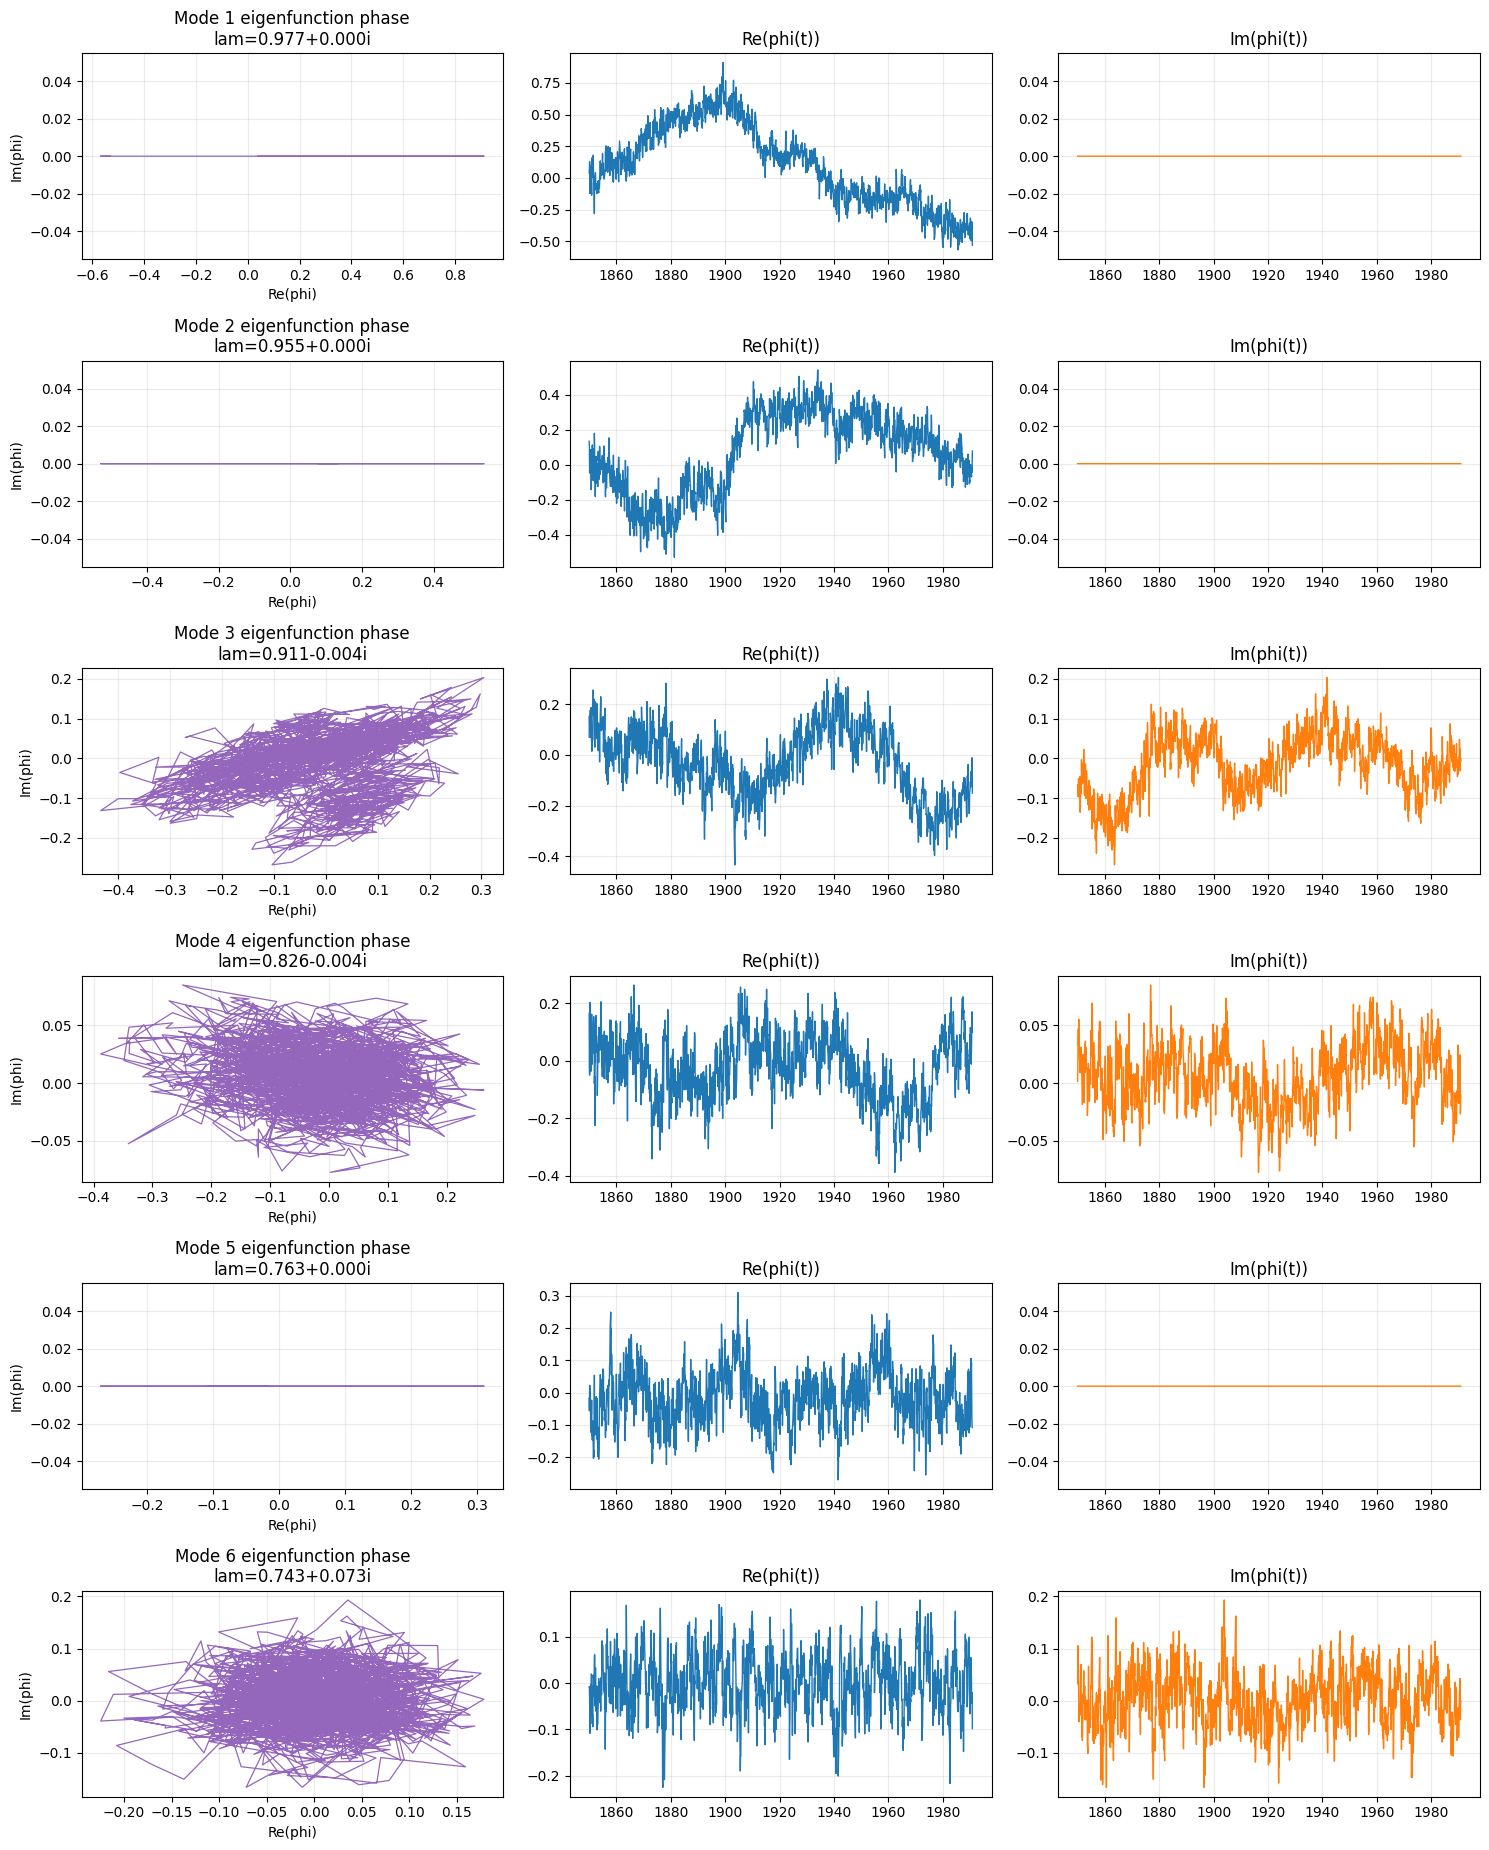

Eigenfunction diagnostics for selected modes:
1. lambda = 0.977445+0.000000i, |lambda|=0.977445
2. lambda = 0.955064+0.000000i, |lambda|=0.955064
3. lambda = 0.910537-0.004149i, |lambda|=0.910546
4. lambda = 0.826279-0.003684i, |lambda|=0.826287
5. lambda = 0.762645+0.000000i, |lambda|=0.762645
6. lambda = 0.742749+0.073301i, |lambda|=0.746357


In [12]:
required_for_efunc = ["mode_coords", "eigvals", "selected", "time_train", "lag_best"]
missing_efunc = [v for v in required_for_efunc if v not in globals()]
if missing_efunc:
    raise RuntimeError(
        "Run the top-modes cell first to populate eigvals/mode_coords/selected. "
        f"Missing: {missing_efunc}"
    )

time_train_lagged = time_train[lag_best - 1 :]
n_modes_plot = len(selected)

fig, axes = plt.subplots(
    n_modes_plot, 3, figsize=(15, 3.1 * n_modes_plot), squeeze=False
)

for row, j in enumerate(selected):
    lam = eigvals[j]
    phi = mode_coords[:, j]  # Koopman eigenfunction evaluated along training trajectory

    ax1 = axes[row, 0]
    ax1.plot(np.real(phi), np.imag(phi), color="tab:purple", linewidth=0.9)
    ax1.set_title(f"Mode {row+1} eigenfunction phase\nlam={lam.real:.3f}{lam.imag:+.3f}i")
    ax1.set_xlabel("Re(phi)")
    ax1.set_ylabel("Im(phi)")
    ax1.grid(alpha=0.25)

    ax2 = axes[row, 1]
    ax2.plot(time_train_lagged, np.real(phi), color="tab:blue", linewidth=1.0)
    ax2.set_title("Re(phi(t))")
    ax2.grid(alpha=0.25)

    ax3 = axes[row, 2]
    ax3.plot(time_train_lagged, np.imag(phi), color="tab:orange", linewidth=1.0)
    ax3.set_title("Im(phi(t))")
    ax3.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("Eigenfunction diagnostics for selected modes:")
for k, j in enumerate(selected, start=1):
    lam = eigvals[j]
    print(f"{k}. lambda = {lam.real:.6f}{lam.imag:+.6f}i, |lambda|={abs(lam):.6f}")